# Cane Corso Growth Prediction - Linear Regression

This notebook is the first experiment in the project.

The goal is to test whether age in months can be used to predict the weight of a Cane Corso using linear regression.

At this stage, the dataset is a small prototype dataset and is not real veterinary data.


## Problem Statement

Many owners of large-breed dogs want to understand whether their dog is growing in an expected way.

In this first experiment, I use a very simple regression setup:

- Input variable: age in months
- Target variable: weight in kilograms

This is only a first step. More features and better models can be added later.


## Mathematical Idea

The first model will use a simple linear regression equation:

$$ y = b_0 + b_1x $$

Where:

- $x$ is the age in months
- $y$ is the predicted weight in kilograms
- $b_0$ is the intercept
- $b_1$ is the coefficient for age


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
data_path = '../data/prototype/cane_corso_growth_sample.csv'
df = pd.read_csv(data_path)
df.head()


,dog_id,dog_name,sex,age_months,weight_kg,height_cm,activity_level,source_type
0,1,Ares,male,2,9.5,32,medium,prototype
1,1,Ares,male,3,14.2,38,medium,prototype
2,1,Ares,male,4,20.1,45,medium,prototype
3,1,Ares,male,5,26.4,51,medium,prototype
4,1,Ares,male,6,31.8,56,medium,prototype


## Initial Data Exploration

Before training a model, I first check the size, structure, and basic statistics of the dataset.

This helps me understand what data I have and whether the values look usable for a first regression experiment.

In [3]:
df.shape

(32, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dog_id          32 non-null     int64  
 1   dog_name        32 non-null     str    
 2   sex             32 non-null     str    
 3   age_months      32 non-null     int64  
 4   weight_kg       32 non-null     float64
 5   height_cm       32 non-null     int64  
 6   activity_level  32 non-null     str    
 7   source_type     32 non-null     str    
dtypes: float64(1), int64(3), str(4)
memory usage: 2.1 KB


In [5]:
df.describe()

,dog_id,age_months,weight_kg,height_cm
count,32.000000,32.000000,32.000000,32.00000
mean,2.500000,6.250000,27.437500,50.53125
std,1.135924,3.321484,12.550922,11.55627
min,1.000000,2.000000,8.100000,30.00000
25%,1.750000,3.750000,16.675000,41.50000
50%,2.500000,5.500000,27.250000,52.00000
75%,3.250000,8.500000,38.550000,61.00000
max,4.000000,12.000000,49.100000,68.00000


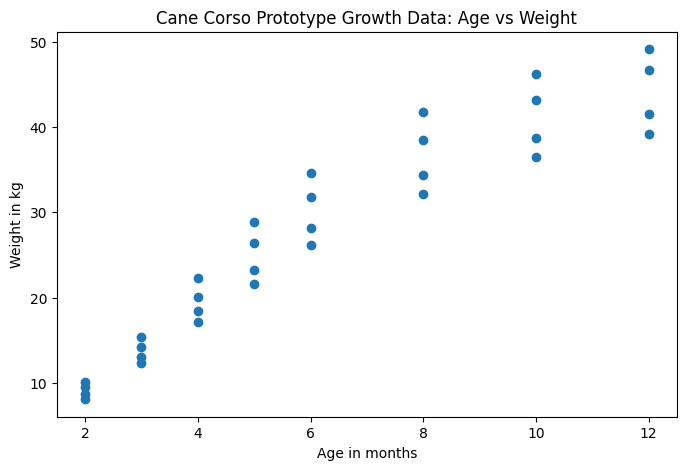

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(df["age_months"], df["weight_kg"])
plt.xlabel("Age in months")
plt.ylabel("Weight in kg")
plt.title("Cane Corso Prototype Growth Data: Age vs Weight")
plt.show()

## First Linear Regression Model

In this section, I train the first simple linear regression model.

The model uses age in months as the input feature and weight in kilograms as the target value.

In [7]:
X = df[["age_months"]]
y = df["weight_kg"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

predictions = pd.DataFrame({
    "actual_weight_kg": y_test.values,
    "predicted_weight_kg": y_pred.round(2)
})

predictions

,actual_weight_kg,predicted_weight_kg
0,32.1,34.79
1,41.5,49.03
2,8.1,13.43
3,15.4,16.99
4,8.7,13.43
5,13.1,16.99
6,36.5,41.91
7,12.3,16.99


In [8]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2]
})

metrics

,Metric,Value
0,MAE,4.480092
1,MSE,22.933348
2,RMSE,4.788877
3,R2 Score,0.855636


In [9]:
print("Intercept:", model.intercept_)
print("Age coefficient:", model.coef_[0])

Intercept: 6.308015768725344
Age coefficient: 3.5599211563731954


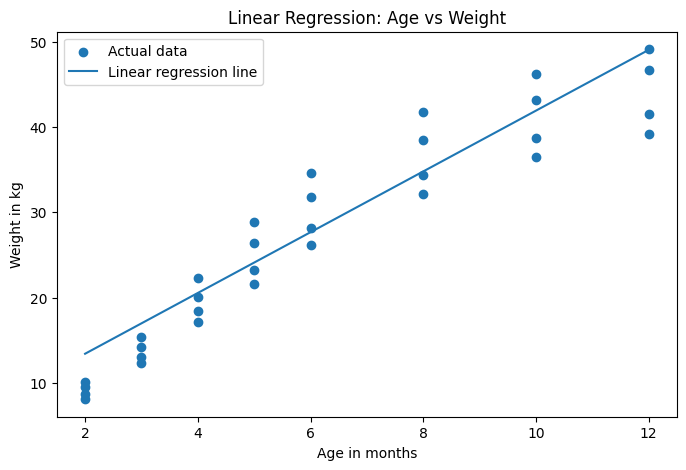

In [10]:
age_values = pd.DataFrame({
    "age_months": sorted(df["age_months"].unique())
})

predicted_weights = model.predict(age_values)

plt.figure(figsize=(8, 5))
plt.scatter(df["age_months"], df["weight_kg"], label="Actual data")
plt.plot(age_values["age_months"], predicted_weights, label="Linear regression line")
plt.xlabel("Age in months")
plt.ylabel("Weight in kg")
plt.title("Linear Regression: Age vs Weight")
plt.legend()
plt.show()

## First Linear Regression Model

In this section, I train the first simple linear regression model.

The model uses age in months as the input feature and weight in kilograms as the target value.

In [11]:
X = df[["age_months"]]
y = df["weight_kg"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

predictions = pd.DataFrame({
    "actual_weight_kg": y_test.values,
    "predicted_weight_kg": y_pred.round(2)
})

predictions

,actual_weight_kg,predicted_weight_kg
0,32.1,34.79
1,41.5,49.03
2,8.1,13.43
3,15.4,16.99
4,8.7,13.43
5,13.1,16.99
6,36.5,41.91
7,12.3,16.99


In [12]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2]
})

metrics

,Metric,Value
0,MAE,4.480092
1,MSE,22.933348
2,RMSE,4.788877
3,R2 Score,0.855636


In [13]:
print("Intercept:", model.intercept_)
print("Age coefficient:", model.coef_[0])

Intercept: 6.308015768725344
Age coefficient: 3.5599211563731954


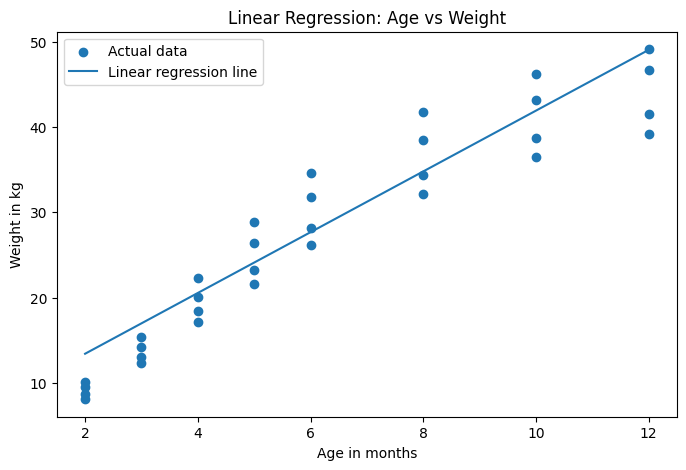

In [14]:
age_values = pd.DataFrame({
    "age_months": sorted(df["age_months"].unique())
})

predicted_weights = model.predict(age_values)

plt.figure(figsize=(8, 5))
plt.scatter(df["age_months"], df["weight_kg"], label="Actual data")
plt.plot(age_values["age_months"], predicted_weights, label="Linear regression line")
plt.xlabel("Age in months")
plt.ylabel("Weight in kg")
plt.title("Linear Regression: Age vs Weight")
plt.legend()
plt.show()

## Result Interpretation

The first linear regression model shows how weight changes with age in the prototype dataset.

The model uses only one feature: age in months. Because of this, it is easy to understand, but it is also limited.

The evaluation metrics help me check how close the predictions are to the actual values.

- MAE shows the average prediction error in kilograms.
- RMSE gives more weight to larger errors.
- R2 Score shows how much of the variation in weight is explained by age.

This first experiment is useful as a baseline model. However, real dog growth depends on more factors than age alone, such as sex, genetics, nutrition, activity level, health, and environment.

Because of that, this model should not be used as a veterinary tool. It is only a first educational machine learning experiment.

## Polynomial Regression

The previous model used a straight line to predict weight from age.

Dog growth is usually not perfectly linear. Puppies often grow faster in the first months and then the growth speed becomes slower.

For this reason, I will test a polynomial regression model as an extension of simple linear regression.

In [15]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [16]:
X = df[["age_months"]]
y = df["weight_kg"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

poly_model = Pipeline([
    ("polynomial_features", PolynomialFeatures(degree=2)),
    ("linear_regression", LinearRegression())
])

poly_model.fit(X_train, y_train)

poly_y_pred = poly_model.predict(X_test)

poly_predictions = pd.DataFrame({
    "actual_weight_kg": y_test.values,
    "predicted_weight_kg": poly_y_pred.round(2)
})

poly_predictions

,actual_weight_kg,predicted_weight_kg
0,32.1,37.35
1,41.5,45.40
2,8.1,8.47
3,15.4,14.69
4,8.7,8.47
5,13.1,14.69
6,36.5,42.49
7,12.3,14.69


In [17]:
poly_mae = mean_absolute_error(y_test, poly_y_pred)
poly_mse = mean_squared_error(y_test, poly_y_pred)
poly_rmse = poly_mse ** 0.5
poly_r2 = r2_score(y_test, poly_y_pred)

poly_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Polynomial Regression": [poly_mae, poly_mse, poly_rmse, poly_r2]
})

poly_metrics

,Metric,Polynomial Regression
0,MAE,2.553559
1,MSE,10.949067
2,RMSE,3.308937
3,R2 Score,0.931076


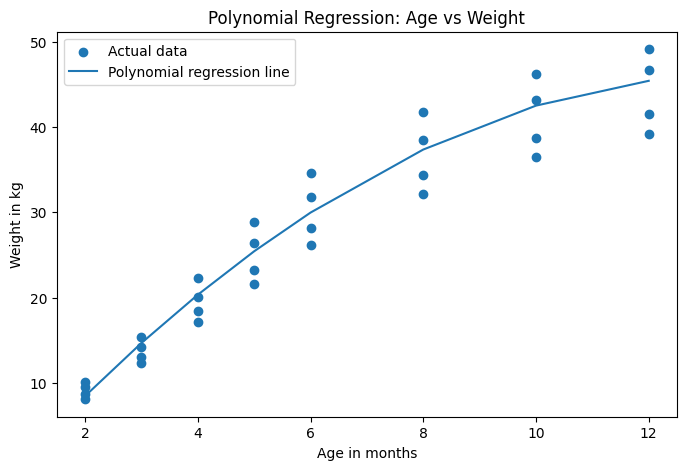

In [18]:
age_range = pd.DataFrame({
    "age_months": sorted(df["age_months"].unique())
})

poly_predicted_weights = poly_model.predict(age_range)

plt.figure(figsize=(8, 5))
plt.scatter(df["age_months"], df["weight_kg"], label="Actual data")
plt.plot(age_range["age_months"], poly_predicted_weights, label="Polynomial regression line")
plt.xlabel("Age in months")
plt.ylabel("Weight in kg")
plt.title("Polynomial Regression: Age vs Weight")
plt.legend()
plt.show()

### Polynomial Regression Interpretation

The polynomial regression model allows the prediction curve to bend instead of using only a straight line.

This can be useful for growth data because growth is often faster at early ages and slower later.

However, this is still a simple model because it uses only age in months as the input feature. More realistic models should also include sex, height, activity level, nutrition, and other factors.

## Multi-Dimensional Linear Regression

The previous models used only age in months as the input feature.

In a real growth analysis problem, weight can depend on more than one factor. For this reason, I will test a multi-dimensional linear regression model.

This model will use:

- age in months
- height in centimeters
- sex
- activity level

Categorical values such as sex and activity level must be converted into numeric values before training the model.

In [19]:
multi_features = pd.get_dummies(
    df[["age_months", "height_cm", "sex", "activity_level"]],
    drop_first=True
)

multi_target = df["weight_kg"]

multi_features.head()

,age_months,height_cm,sex_male,activity_level_low,activity_level_medium
0,2,32,True,False,True
1,3,38,True,False,True
2,4,45,True,False,True
3,5,51,True,False,True
4,6,56,True,False,True


In [20]:
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    multi_features,
    multi_target,
    test_size=0.25,
    random_state=42
)

multi_model = LinearRegression()
multi_model.fit(X_train_multi, y_train_multi)

multi_y_pred = multi_model.predict(X_test_multi)

multi_predictions = pd.DataFrame({
    "actual_weight_kg": y_test_multi.values,
    "predicted_weight_kg": multi_y_pred.round(2)
})

multi_predictions

,actual_weight_kg,predicted_weight_kg
0,32.1,32.01
1,41.5,41.80
2,8.1,4.57
3,15.4,16.83
4,8.7,6.01
5,13.1,11.93
6,36.5,36.59
7,12.3,10.49


In [21]:
multi_mae = mean_absolute_error(y_test_multi, multi_y_pred)
multi_mse = mean_squared_error(y_test_multi, multi_y_pred)
multi_rmse = multi_mse ** 0.5
multi_r2 = r2_score(y_test_multi, multi_y_pred)

multi_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Multi-Dimensional Linear Regression": [multi_mae, multi_mse, multi_rmse, multi_r2]
})

multi_metrics

,Metric,Multi-Dimensional Linear Regression
0,MAE,1.389803
1,MSE,3.316104
2,RMSE,1.821017
3,R2 Score,0.979125


In [22]:
multi_coefficients = pd.DataFrame({
    "Feature": multi_features.columns,
    "Coefficient": multi_model.coef_
})

multi_coefficients

,Feature,Coefficient
0,age_months,1.078118
1,height_cm,0.806786
2,sex_male,1.565315
3,activity_level_low,-1.555904
4,activity_level_medium,-0.916491


### Multi-Dimensional Regression Interpretation

The multi-dimensional linear regression model uses more information than the first simple linear regression model.

This makes the experiment more realistic because dog weight can depend on age, height, sex, and activity level.

However, the dataset is still small and only a prototype. The results should be interpreted carefully. This model is useful for learning how multiple input features can be used in regression, but it is not enough for real veterinary or health-related decisions.

## Regularization: Ridge and Lasso Regression

Linear regression can sometimes become too sensitive to the training data, especially when more features are added.

Regularization is used to control the model coefficients and reduce overfitting.

In this section, I will test two regularized regression models:

- Ridge Regression
- Lasso Regression

Both models will use the same multi-dimensional features from the previous experiment.

In [23]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [24]:
regularized_features = pd.get_dummies(
    df[["age_months", "height_cm", "sex", "activity_level"]],
    drop_first=True
)

regularized_target = df["weight_kg"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    regularized_features,
    regularized_target,
    test_size=0.25,
    random_state=42
)

regularized_features.head()

,age_months,height_cm,sex_male,activity_level_low,activity_level_medium
0,2,32,True,False,True
1,3,38,True,False,True
2,4,45,True,False,True
3,5,51,True,False,True
4,6,56,True,False,True


In [25]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train_reg, y_train_reg)

ridge_y_pred = ridge_model.predict(X_test_reg)

ridge_mae = mean_absolute_error(y_test_reg, ridge_y_pred)
ridge_mse = mean_squared_error(y_test_reg, ridge_y_pred)
ridge_rmse = ridge_mse ** 0.5
ridge_r2 = r2_score(y_test_reg, ridge_y_pred)

ridge_results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Ridge Regression": [ridge_mae, ridge_mse, ridge_rmse, ridge_r2]
})

ridge_results

,Metric,Ridge Regression
0,MAE,1.136788
1,MSE,1.972685
2,RMSE,1.404523
3,R2 Score,0.987582


In [26]:
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.1, max_iter=10000))
])

lasso_model.fit(X_train_reg, y_train_reg)

lasso_y_pred = lasso_model.predict(X_test_reg)

lasso_mae = mean_absolute_error(y_test_reg, lasso_y_pred)
lasso_mse = mean_squared_error(y_test_reg, lasso_y_pred)
lasso_rmse = lasso_mse ** 0.5
lasso_r2 = r2_score(y_test_reg, lasso_y_pred)

lasso_results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Lasso Regression": [lasso_mae, lasso_mse, lasso_rmse, lasso_r2]
})

lasso_results

,Metric,Lasso Regression
0,MAE,1.257905
1,MSE,2.817570
2,RMSE,1.678562
3,R2 Score,0.982264


In [27]:
regularization_comparison = pd.DataFrame({
    "Model": ["Ridge Regression", "Lasso Regression"],
    "MAE": [ridge_mae, lasso_mae],
    "MSE": [ridge_mse, lasso_mse],
    "RMSE": [ridge_rmse, lasso_rmse],
    "R2 Score": [ridge_r2, lasso_r2]
})

regularization_comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Ridge Regression,1.136788,1.972685,1.404523,0.987582
1,Lasso Regression,1.257905,2.817570,1.678562,0.982264


### Regularization Interpretation

Ridge and Lasso Regression are regularized versions of linear regression.

Ridge reduces the size of the coefficients but usually keeps all features in the model.

Lasso can reduce some coefficients strongly and may even push some of them close to zero.

In this prototype project, regularization is useful because the model uses multiple input features. However, the dataset is still small, so the results should be interpreted only as an educational experiment.

## RANSAC Robust Regression

RANSAC is a robust regression method that can reduce the influence of outliers.

This is useful because real-world measurements may contain errors. For example, a dog weight value may be entered incorrectly by the owner.

In this experiment, I add one artificial outlier to the prototype dataset and compare a normal linear regression model with a RANSAC regression model.

In [28]:
from sklearn.linear_model import RANSACRegressor

In [29]:
outlier = pd.DataFrame({
    "dog_id": [99],
    "dog_name": ["Outlier"],
    "sex": ["male"],
    "age_months": [6],
    "weight_kg": [65.0],
    "height_cm": [56],
    "activity_level": ["medium"],
    "source_type": ["artificial_outlier"]
})

ransac_df = pd.concat([df, outlier], ignore_index=True)

ransac_df.tail()

,dog_id,dog_name,sex,age_months,weight_kg,height_cm,activity_level,source_type
28,4,Luna,female,6,26.2,51,low,prototype
29,4,Luna,female,8,32.1,56,low,prototype
30,4,Luna,female,10,36.5,59,low,prototype
31,4,Luna,female,12,39.2,61,low,prototype
32,99,Outlier,male,6,65.0,56,medium,artificial_outlier


In [30]:
X_ransac = ransac_df[["age_months"]]
y_ransac = ransac_df["weight_kg"]

normal_model_with_outlier = LinearRegression()
normal_model_with_outlier.fit(X_ransac, y_ransac)

ransac_model = RANSACRegressor(
    estimator=LinearRegression(),
    residual_threshold=5.0,
    random_state=42
)

ransac_model.fit(X_ransac, y_ransac)

age_range_ransac = pd.DataFrame({
    "age_months": sorted(ransac_df["age_months"].unique())
})

normal_outlier_predictions = normal_model_with_outlier.predict(age_range_ransac)
ransac_predictions = ransac_model.predict(age_range_ransac)

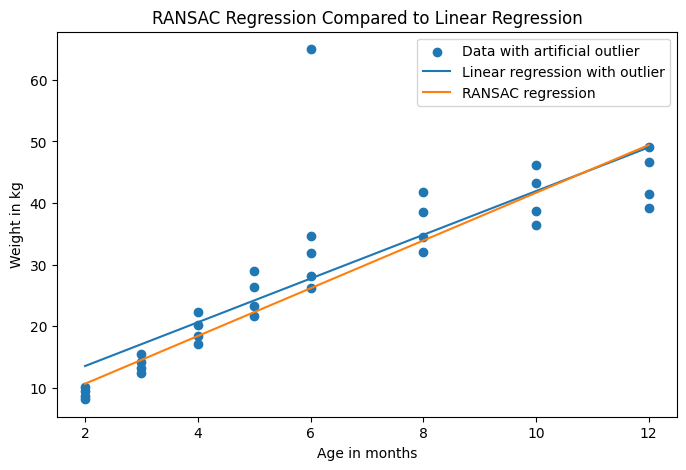

In [31]:
plt.figure(figsize=(8, 5))

plt.scatter(
    ransac_df["age_months"],
    ransac_df["weight_kg"],
    label="Data with artificial outlier"
)

plt.plot(
    age_range_ransac["age_months"],
    normal_outlier_predictions,
    label="Linear regression with outlier"
)

plt.plot(
    age_range_ransac["age_months"],
    ransac_predictions,
    label="RANSAC regression"
)

plt.xlabel("Age in months")
plt.ylabel("Weight in kg")
plt.title("RANSAC Regression Compared to Linear Regression")
plt.legend()
plt.show()

### RANSAC Interpretation

The artificial outlier represents a possible measurement or data entry error.

A normal linear regression model can be influenced by this outlier because it tries to fit all data points.

RANSAC tries to focus on the main pattern in the data and reduce the influence of abnormal points.

This makes RANSAC useful for real-world datasets where some values may be incorrect or unusual.

## Final Model Comparison

In this section, I compare the regression models tested in this notebook.

The comparison helps me understand which model performs better on the current prototype dataset.

The models are compared using:

- MAE
- RMSE
- R2 Score

Lower MAE and RMSE are better. Higher R2 Score is better.

In [32]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Polynomial Regression",
        "Multi-Dimensional Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "Main Features": [
        "age_months",
        "age_months with polynomial degree 2",
        "age_months, height_cm, sex, activity_level",
        "age_months, height_cm, sex, activity_level",
        "age_months, height_cm, sex, activity_level"
    ],
    "MAE": [
        mae,
        poly_mae,
        multi_mae,
        ridge_mae,
        lasso_mae
    ],
    "RMSE": [
        rmse,
        poly_rmse,
        multi_rmse,
        ridge_rmse,
        lasso_rmse
    ],
    "R2 Score": [
        r2,
        poly_r2,
        multi_r2,
        ridge_r2,
        lasso_r2
    ]
})

final_model_comparison

,Model,Main Features,MAE,RMSE,R2 Score
0,Simple Linear Regression,age_months,4.480092,4.788877,0.855636
1,Polynomial Regression,age_months with polynomial degree 2,2.553559,3.308937,0.931076
2,Multi-Dimensional Linear Regression,"age_months, height_cm, sex, activity_level",1.389803,1.821017,0.979125
3,Ridge Regression,"age_months, height_cm, sex, activity_level",1.136788,1.404523,0.987582
4,Lasso Regression,"age_months, height_cm, sex, activity_level",1.257905,1.678562,0.982264


In [33]:
final_model_comparison.sort_values(by="RMSE")

,Model,Main Features,MAE,RMSE,R2 Score
3,Ridge Regression,"age_months, height_cm, sex, activity_level",1.136788,1.404523,0.987582
4,Lasso Regression,"age_months, height_cm, sex, activity_level",1.257905,1.678562,0.982264
2,Multi-Dimensional Linear Regression,"age_months, height_cm, sex, activity_level",1.389803,1.821017,0.979125
1,Polynomial Regression,age_months with polynomial degree 2,2.553559,3.308937,0.931076
0,Simple Linear Regression,age_months,4.480092,4.788877,0.855636


## Final Notes for This Topic

The first simple linear regression model is easy to understand and works as a baseline.

Polynomial regression is useful because dog growth is not always perfectly linear.

Multi-dimensional regression is more realistic because it uses more than one feature.

Ridge and Lasso add regularization, which can help control model coefficients when more features are used.

RANSAC is useful when the dataset may contain outliers or incorrect measurements.

At this stage, the dataset is still a small prototype dataset, so the results should not be interpreted as real veterinary conclusions. The main goal is to apply the course topic step by step and understand how different regression methods behave.